# هذي النسخه المبسطه وتطبق كل المفاهيم وهي اول وحده سويتها

## Install Dependencies


In [3]:
%pip install -q  mlflow dagshub scikit-learn tensorflow


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install python-dotenv

## Imports

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import mlflow
import mlflow.keras

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.18.0
GPU: []


In [6]:
import os

## Dataset

In [13]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/archive-3/training",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/archive-3/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/archive-3/evaluation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

Found 9866 files belonging to 11 classes.
Found 3430 files belonging to 11 classes.
Found 3347 files belonging to 11 classes.
Classes: ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']


## Data Augmentation

In [14]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

## Build EfficientNet Model

In [15]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

inputs = tf.keras.Input(shape=(224,224,3))

x = data_aug(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(128, activation="relu")(x)

outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,220,078 (16.10 MB)

 Trainable params: 4,175,495 (15.93 MB)

 Non-trainable params: 44,583 (174.16 KB)

## Experiment 1 — Feature Extraction

In [16]:
base_model.trainable = False

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fe = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 974s 3s/step - accuracy: 0.7036 - loss: 0.9328 - val_accuracy: 0.8706 - val_loss: 0.3907
Epoch 2/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 982s 3s/step - accuracy: 0.8663 - loss: 0.3939 - val_accuracy: 0.8875 - val_loss: 0.3810
Epoch 3/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 728s 2s/step - accuracy: 0.8953 - loss: 0.3071 - val_accuracy: 0.8802 - val_loss: 0.3948
Epoch 4/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 710s 2s/step - accuracy: 0.9131 - loss: 0.2535 - val_accuracy: 0.8831 - val_loss: 0.3852
Epoch 5/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 724s 2s/step - accuracy: 0.9231 - loss: 0.2243 - val_accuracy: 0.8872 - val_loss: 0.4126
Epoch 6/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 456s 1s/step - accuracy: 0.9318 - loss: 0.2042 - val_accuracy: 0.8819 - val_loss: 0.4204
Epoch 7/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 216s 700ms/step - accuracy: 0.9370 - loss: 0.1746 - val_accuracy: 0.8808 - val_loss: 0.4372
Epoch 8/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 221s 716ms/step - accuracy: 0.9452 - loss: 0.1616 - va

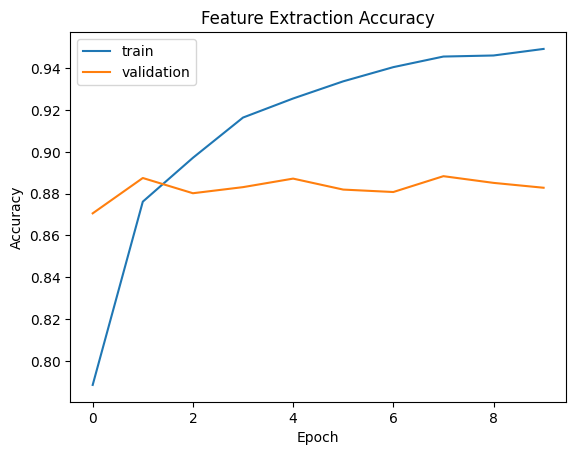

In [17]:
plt.plot(history_fe.history["accuracy"], label="train")
plt.plot(history_fe.history["val_accuracy"], label="validation")

plt.title("Feature Extraction Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

## Experiment 2 — Fine-Tuning


In [18]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - accuracy: 0.8132 - loss: 0.5761 - val_accuracy: 0.8376 - val_loss: 0.6310
Epoch 2/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 340s 1s/step - accuracy: 0.8656 - loss: 0.4139 - val_accuracy: 0.8449 - val_loss: 0.5918
Epoch 3/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 330s 1s/step - accuracy: 0.8874 - loss: 0.3436 - val_accuracy: 0.8554 - val_loss: 0.5600
Epoch 4/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 290s 938ms/step - accuracy: 0.9052 - loss: 0.2815 - val_accuracy: 0.8633 - val_loss: 0.5358
Epoch 5/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 305s 989ms/step - accuracy: 0.9030 - loss: 0.2697 - val_accuracy: 0.8650 - val_loss: 0.5187


##  Experiment 3 — Gradual Unfreezing

### ٢ pahases

In [19]:
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_gu1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy: 0.9193 - loss: 0.2325 - val_accuracy: 0.8700 - val_loss: 0.5046
Epoch 2/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - accuracy: 0.9301 - loss: 0.2066 - val_accuracy: 0.8749 - val_loss: 0.4924
Epoch 3/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.9277 - loss: 0.2076 - val_accuracy: 0.8770 - val_loss: 0.4829
Epoch 4/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - accuracy: 0.9369 - loss: 0.1775 - val_accuracy: 0.8790 - val_loss: 0.4790
Epoch 5/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.9383 - loss: 0.1751 - val_accuracy: 0.8822 - val_loss: 0.4725


In [20]:
for layer in base_model.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_gu2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 428s 1s/step - accuracy: 0.9473 - loss: 0.1484 - val_accuracy: 0.8810 - val_loss: 0.4643
Epoch 2/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 410s 1s/step - accuracy: 0.9508 - loss: 0.1410 - val_accuracy: 0.8828 - val_loss: 0.4611
Epoch 3/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 416s 1s/step - accuracy: 0.9552 - loss: 0.1280 - val_accuracy: 0.8848 - val_loss: 0.4565
Epoch 4/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 413s 1s/step - accuracy: 0.9551 - loss: 0.1277 - val_accuracy: 0.8843 - val_loss: 0.4534
Epoch 5/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.9559 - loss: 0.1238 - val_accuracy: 0.8848 - val_loss: 0.4526


## Experiment 4 — Layer-wise Learning Rate

In [21]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_lwlr = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 492s 2s/step - accuracy: 0.9572 - loss: 0.1286 - val_accuracy: 0.8878 - val_loss: 0.4459
Epoch 2/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 555s 2s/step - accuracy: 0.9673 - loss: 0.1000 - val_accuracy: 0.8953 - val_loss: 0.4450
Epoch 3/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 419s 1s/step - accuracy: 0.9719 - loss: 0.0869 - val_accuracy: 0.8968 - val_loss: 0.4397
Epoch 4/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 376s 1s/step - accuracy: 0.9751 - loss: 0.0770 - val_accuracy: 0.8942 - val_loss: 0.4326
Epoch 5/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.9775 - loss: 0.0691 - val_accuracy: 0.8968 - val_loss: 0.4284


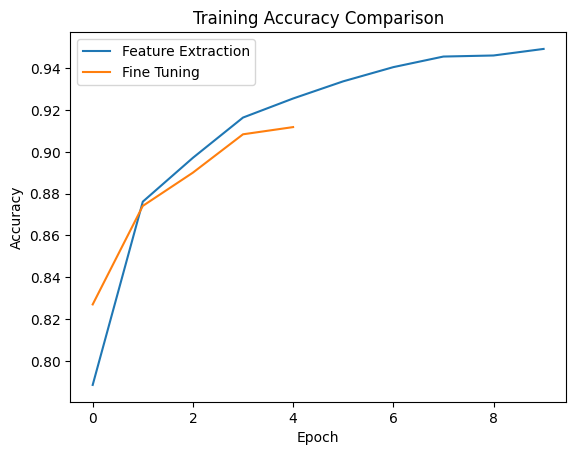

In [22]:
plt.plot(history_fe.history["accuracy"], label="Feature Extraction")
plt.plot(history_ft.history["accuracy"], label="Fine Tuning")

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

In [23]:
loss, acc = model.evaluate(test_ds)

print("Test Accuracy:", acc)
print("Test Loss:", loss)

105/105 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.9167 - loss: 0.3270
Test Accuracy: 0.9184344410896301
Test Loss: 0.3168710172176361


In [24]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━

2026-03-15 00:42:20.028911: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


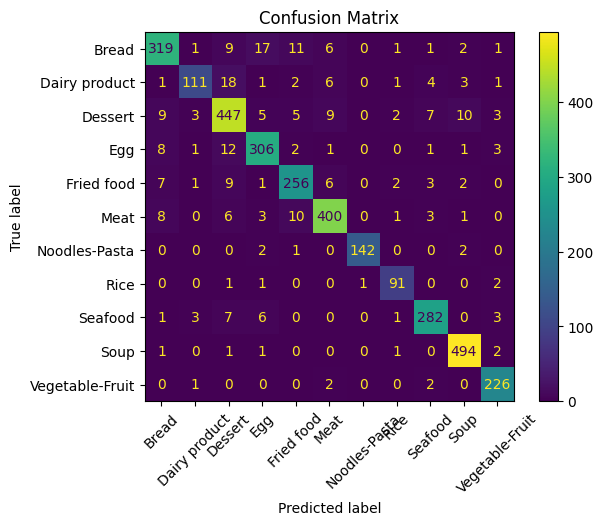

In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=class_names,
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

## MLflow Tracking (Bonus)

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

DAGSHUB_REPO = os.getenv("DAGSHUB_REPO")
DAGSHUB_TOKEN = os.getenv("DAGSHUB_TOKEN")

In [ ]:
DAGSHUB_USERNAME = "MoojProject"

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN

TRACKING_URI = f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow"
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("food11-efficientnet")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: https://dagshub.com/MoojProject/efficientnet-food.mlflow


In [27]:
mlflow.set_experiment("efficientnet_food11")

with mlflow.start_run():

    mlflow.log_param("model", "EfficientNetB0")

    mlflow.log_metric("test_accuracy", acc)
    mlflow.log_metric("test_loss", loss)

    mlflow.keras.log_model(model, "model")

2026/03/15 00:42:23 INFO mlflow.tracking.fluent: Experiment with name 'efficientnet_food11' does not exist. Creating a new experiment.
2026/03/15 00:42:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 00:42:28 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run burly-panda-862 at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/3/runs/fd74a40e57d9429286bd1a52aa2dd77f
🧪 View experiment at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/3


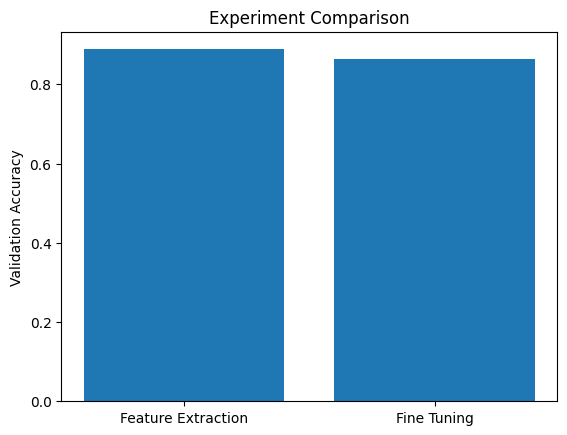

In [28]:
experiments = ["Feature Extraction", "Fine Tuning"]

accuracy = [
    max(history_fe.history["val_accuracy"]),
    max(history_ft.history["val_accuracy"])
]

plt.bar(experiments, accuracy)

plt.title("Experiment Comparison")
plt.ylabel("Validation Accuracy")

plt.show()